<a href="https://colab.research.google.com/github/asdiFlv3/PHAS0056_assignments/blob/main/mini_project/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount drive, load prediction and parse them

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load files
rel_df = pd.read_csv("/content/drive/MyDrive/immigration_models/relevance_progress.csv")
sent_df = pd.read_csv("/content/drive/MyDrive/immigration_models/sentiment_progress.csv")

# parse dates
rel_df["date"] = pd.to_datetime(rel_df["date"], dayfirst=False, errors="coerce")
sent_df["date"] = pd.to_datetime(sent_df["date"], dayfirst=False, errors="coerce")

rel_df["year"] = rel_df["date"].dt.year
sent_df["year"] = sent_df["date"].dt.year

# combine Labour/Co-operative with Labour
rel_df["current_party"] = rel_df["current_party"].replace(
    "Labour/Co-operative", "Labour"
)
sent_df["current_party"] = sent_df["current_party"].replace(
    "Labour/Co-operative", "Labour"
)


### Sanity checks, group Labour and Co-operatives together, group parties that have <100 snippets together

In [ ]:
# little sanity check
print("=== Parties in relevance data ===")
print(rel_df["current_party"].value_counts())

print("\n=== Parties in sentiment data ===")
print(sent_df["current_party"].value_counts())

=== Parties in relevance data ===
current_party
Conservative                          40113
Labour                                25595
Scottish National Party                6569
Liberal Democrat                       4093
DUP                                     707
Plaid Cymru                             552
Speaker                                 186
Green                                   142
Social Democratic and Labour Party      111
Independent                              99
Alliance                                 76
UKIP                                     73
Workers Party                            39
Name: count, dtype: int64

=== Parties in sentiment data ===
current_party
Conservative                          26638
Labour                                16724
Scottish National Party                5027
Liberal Democrat                       2414
DUP                                     435
Plaid Cymru                             269
Speaker                                 1

In [ ]:
# Check what's actually in there
print(rel_df["current_party"].dtype)
print(rel_df[rel_df["current_party"] == "nan"].shape[0])  # string "nan"
print(rel_df[rel_df["current_party"].isna()].shape[0])     # actual NaN

object
0
184299


In [ ]:
# fill NaN party values first
rel_df["current_party"] = rel_df["current_party"].fillna("Unknown")
sent_df["current_party"] = sent_df["current_party"].fillna("Unknown")

# group small parties that have snippet number < 100 into others
party_counts = rel_df["current_party"].value_counts()
print(party_counts)

small_parties = party_counts[party_counts < 100].index.tolist()
print(f"\nParties grouped into 'Other': {small_parties}")

rel_df["current_party"] = rel_df["current_party"].apply(
    lambda x: "Other" if x in small_parties else x
)
sent_df["current_party"] = sent_df["current_party"].apply(
    lambda x: "Other" if x in small_parties else x
)

print("\n=== After grouping ===")
print(rel_df["current_party"].value_counts())

current_party
Unknown                               184299
Conservative                           40113
Labour                                 25595
Scottish National Party                 6569
Liberal Democrat                        4093
DUP                                      707
Plaid Cymru                              552
Speaker                                  186
Green                                    142
Social Democratic and Labour Party       111
Independent                               99
Alliance                                  76
UKIP                                      73
Workers Party                             39
Name: count, dtype: int64

Parties grouped into 'Other': ['Independent', 'Alliance', 'UKIP', 'Workers Party']

=== After grouping ===
current_party
Unknown                               184299
Conservative                           40113
Labour                                 25595
Scottish National Party                 6569
Liberal Democrat            

### Some UK history events that might have some effects

In [ ]:
events = {
    1948: "Windrush /\nNationality Act",
    1962: "Commonwealth\nImmigrants Act",
    1971: "Immigration\nAct 1971",
    2004: "EU\nenlargement",
    2016: "Brexit\nreferendum",
    2022: "Nationality\nBorders Act\nAsylum Seekers"
}
events_post20s = {
    2004: "EU\nenlargement",
    2016: "Brexit\nreferendum",
    2018: "Windrush\nscandal",
    2022: "Nationality\nBorders Act\nAsylum Seekers"
}

In [ ]:
# functions that will add labels to needed plots
def annotate_events(ax, events, y_position="top"):
    """
    Add vertical dashed lines and labels for historical events.

    ax: the matplotlib axis to annotate
    events: dict of {year: "label"}
    y_position: "top" or "bottom" , where to place the text
    """
    y_min, y_max = ax.get_ylim()

    for year, label in events.items():
        # Vertical dashed line
        ax.axvline(x=year, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)

        # Place label near top or bottom of plot
        if y_position == "top":
            y = y_max - 0.05 * (y_max - y_min)
            va = "top"
        else:
            y = y_min + 0.05 * (y_max - y_min)
            va = "bottom"

        ax.text(
            year, y, label,
            fontsize=7,
            ha="center",
            va=va,
            rotation=0,
            color="dimgrey",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        )

### Plot 1: Immigration relevance frequency density over time
Of all snippets in a given year, what proportion were classified as immigration-relevant?

All plots rolls data in a 5-year window to increase readability and reduce noise

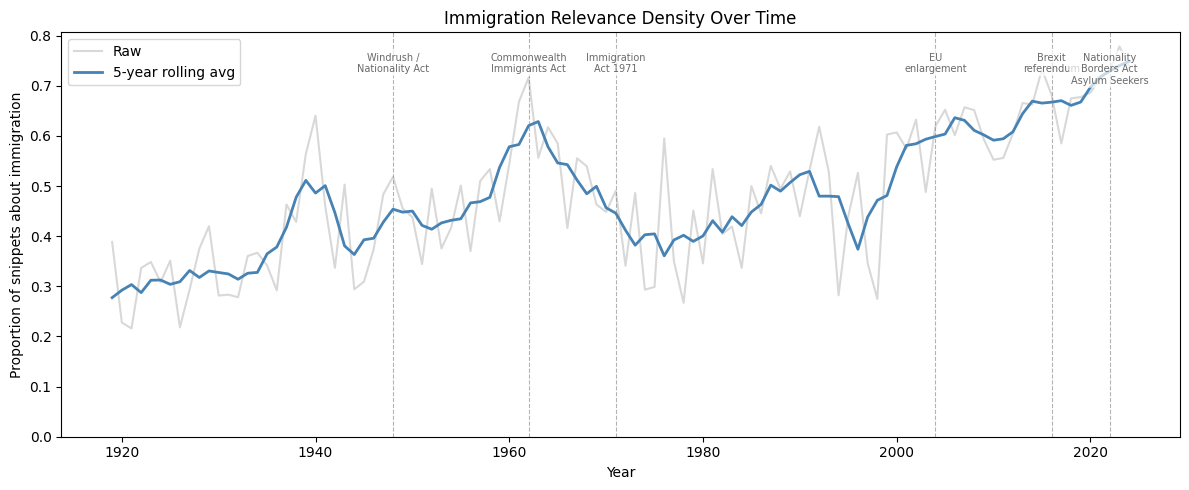

In [ ]:
# group by year: count total snippets and immigration-relevant ones
yearly_total = rel_df.groupby("year").size()
yearly_relevant = rel_df[rel_df["relevance_pred"] == "IMMIGRATION"].groupby("year").size()

# frequency density = relevant / total
relevance_density = (yearly_relevant / yearly_total).dropna()

# smooth with a rolling average (window=5 years)
relevance_smooth = relevance_density.rolling(window=5, center=True, min_periods=2).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(relevance_density.index, relevance_density.values, alpha=0.3, color="grey", label="Raw")
ax.plot(relevance_smooth.index, relevance_smooth.values, color="steelblue", linewidth=2, label="5-year rolling avg")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of snippets about immigration")
ax.set_title("Immigration Relevance Density Over Time")
ax.legend()
ax.set_ylim(bottom=0)
annotate_events(ax, events, y_position="top") # comment this line to remove historical events
plt.tight_layout()
plt.savefig("plot1_relevance_density.png", dpi=150)
plt.show()

### Plot 2: Sentiment frequency density over time (positive, negative, neutral)
Among immigration-relevant snippets each year, what fraction were positive/negative/neutral?

year
1919    0.097674
1920    0.178571
1921    0.245614
1922    0.250329
1923    0.199454
dtype: float64
year
1919    0.429767
1920    0.166667
1921    0.122807
1922    0.114625
1923    0.174863
dtype: float64
year
1919    0.472558
1920    0.654762
1921    0.631579
1922    0.635046
1923    0.625683
dtype: float64


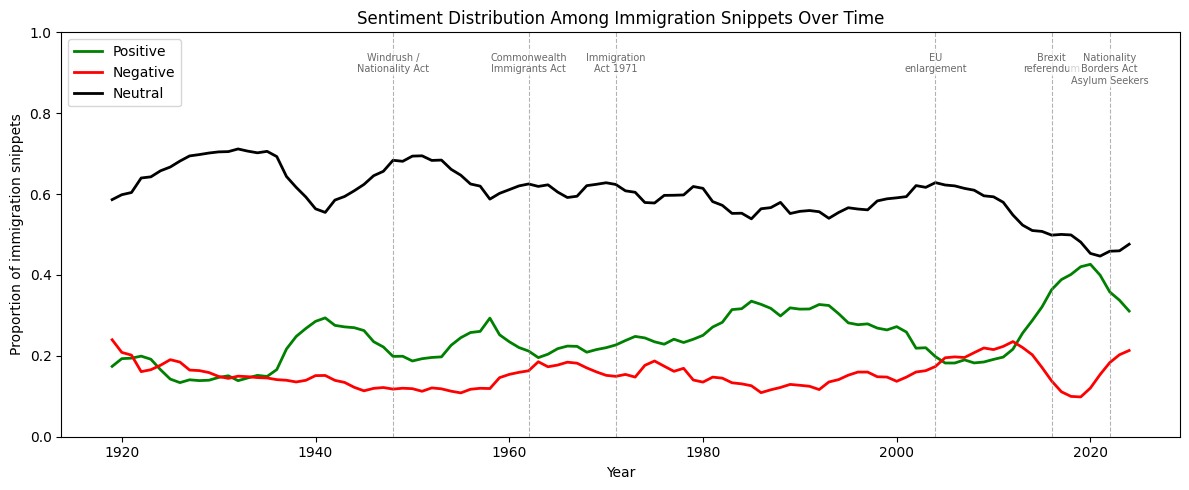

In [ ]:
# count immigration-relevant snippets per year (denominator)
yearly_imm = sent_df.groupby("year").size()

# count each sentiment per year
yearly_pos = sent_df[sent_df["sentiment_pred"] == "POSITIVE"].groupby("year").size()
yearly_neg = sent_df[sent_df["sentiment_pred"] == "NEGATIVE"].groupby("year").size()
yearly_neu = sent_df[sent_df["sentiment_pred"] == "NEUTRAL"].groupby("year").size()

# frequency densities
pos_density = (yearly_pos / yearly_imm).dropna()
neg_density = (yearly_neg / yearly_imm).dropna()
neu_density = (yearly_neu / yearly_imm).dropna()

# san check
print(pos_density.head())
print(neg_density.head())
print(neu_density.head())

# smooth
window = 5
pos_smooth = pos_density.rolling(window=window, center=True, min_periods=2).mean()
neg_smooth = neg_density.rolling(window=window, center=True, min_periods=2).mean()
neu_smooth = neu_density.rolling(window=window, center=True, min_periods=2).mean()

# plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pos_smooth.index, pos_smooth.values, color="g", linewidth=2, label="Positive")
ax.plot(neg_smooth.index, neg_smooth.values, color="r", linewidth=2, label="Negative")
ax.plot(neu_smooth.index, neu_smooth.values, color="k", linewidth=2, label="Neutral")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of immigration snippets")
ax.set_title("Sentiment Distribution Among Immigration Snippets Over Time")
ax.legend()
ax.set_ylim(0, 1)
annotate_events(ax, events, y_position="top") # comment this line to remove historical events
plt.tight_layout()
plt.savefig("plot2_sentiment_density.png", dpi=150)
plt.show()

### Plot 3: The immigration relevance by party

too messy, drop in report

why labour have data before 2000?

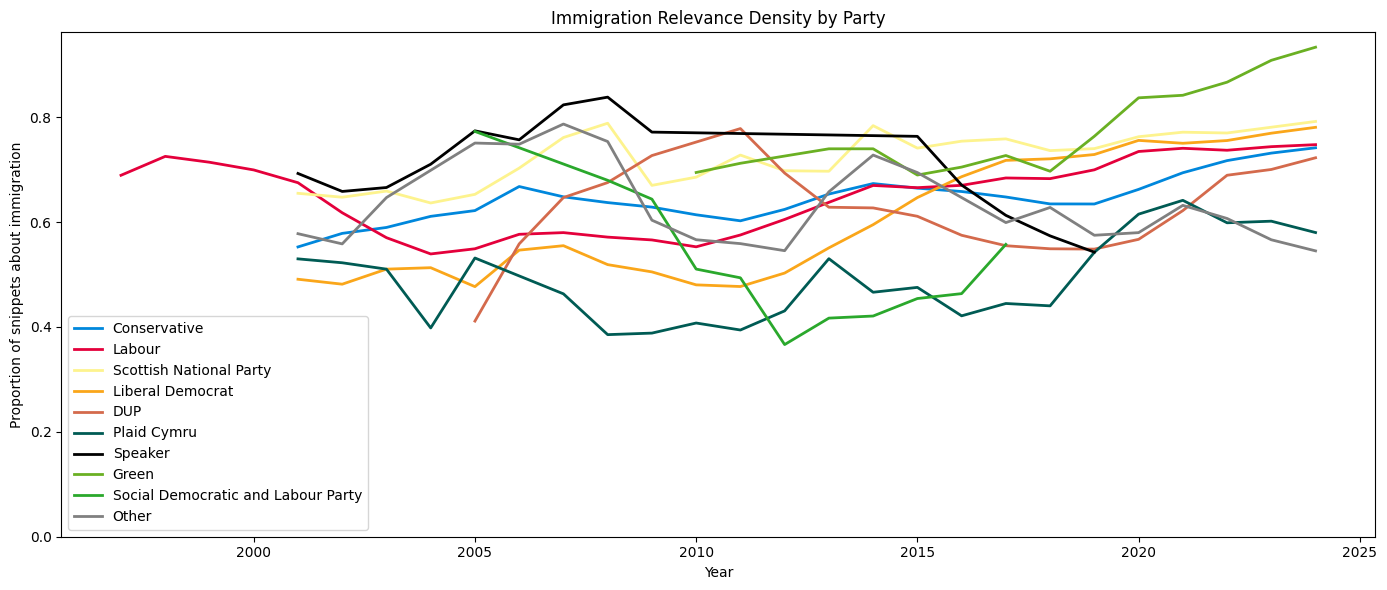

In [ ]:
# party's signature colors
party_colors = {
    "Conservative": "#0087DC",
    "Labour": "#E4003B",
    "Scottish National Party": "#FDF38E",
    "Liberal Democrat": "#FAA61A",
    "DUP": "#D46A4C",
    "Plaid Cymru": "#005B54",
    "Speaker": "#000000",
    "Green": "#6AB023",
    "Social Democratic and Labour Party":"#2AA82C",
    "Other":"#808080"
    }

fig, ax = plt.subplots(figsize=(14, 6))

for party, color in party_colors.items():
    party_data = rel_df[rel_df["current_party"] == party]

    # calculate frequency density of immigration related speeches
    yearly_total_p = party_data.groupby("year").size()
    yearly_rel_p = party_data[party_data["relevance_pred"] == "IMMIGRATION"].groupby("year").size()

    density_p = (yearly_rel_p / yearly_total_p).dropna()

    # smooth
    smooth_p = density_p.rolling(window=5, center=True, min_periods=2).mean()

    ax.plot(smooth_p.index, smooth_p.values, color=color, linewidth=2, label=party)

ax.set_xlabel("Year")
ax.set_ylabel("Proportion of snippets about immigration")
ax.set_title("Immigration Relevance Density by Party")
ax.legend()
ax.set_ylim(bottom=0)
#annotate_events(ax, events_post20s, y_position="top") # comment this line to remove historical events
plt.tight_layout()
plt.savefig("plot3_party_relevance.png", dpi=150)
plt.show()

### Party comparison: sentiment density by party

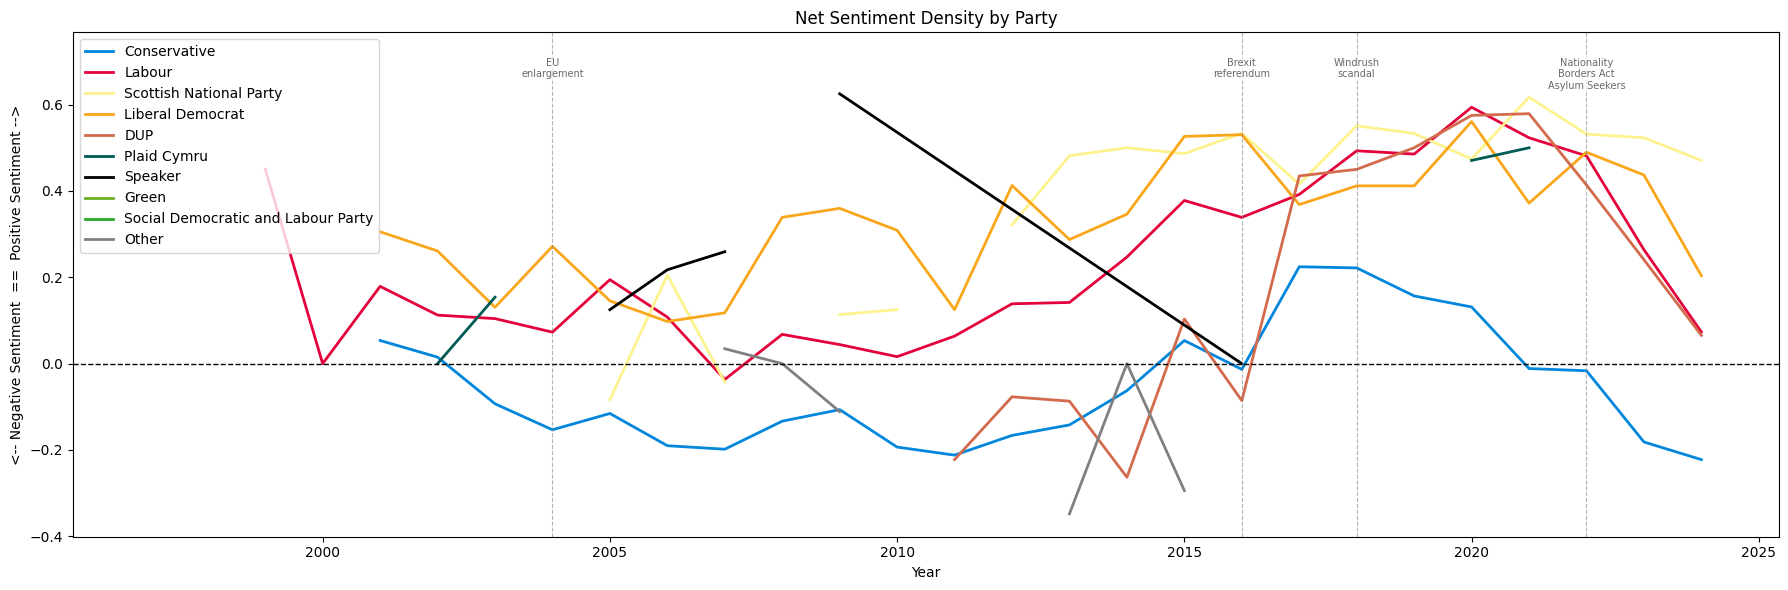

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), sharey=True)

for party, color in party_colors.items():
    party_sent = sent_df[sent_df["current_party"] == party]
    yearly_total_p = party_sent.groupby("year").size()

    # Positive density
    yearly_pos_p = party_sent[party_sent["sentiment_pred"] == "POSITIVE"].groupby("year").size()
    pos_d = (yearly_pos_p / yearly_total_p).dropna()
    pos_s = pos_d.rolling(window=5, center=True, min_periods=2).mean()

    # Negative density
    yearly_neg_p = party_sent[party_sent["sentiment_pred"] == "NEGATIVE"].groupby("year").size()
    neg_d = (yearly_neg_p / yearly_total_p).dropna()
    neg_s = neg_d.rolling(window=5, center=True, min_periods=2).mean()

    # net sentiment = positive - negative
    plotting_d = pos_d.copy() - neg_d.copy()
    axes.plot(plotting_d.index, plotting_d.values, color=color, linewidth=2, label=party)

axes.axhline(0, color='black', linestyle='--', linewidth=1)
axes.set_xlabel("Year")
axes.set_ylabel("<-- Negative Sentiment  ==  Positive Sentiment -->")
axes.set_title("Net Sentiment Density by Party")
axes.legend()
annotate_events(axes, events_post20s, y_position="top") # comment this line to remove historical events
plt.tight_layout()
plt.savefig("plot4_party_sentiment.png", dpi=150)
plt.show()

### Plot above is too messy, get a comparision of the two parties with most seats in House of Common

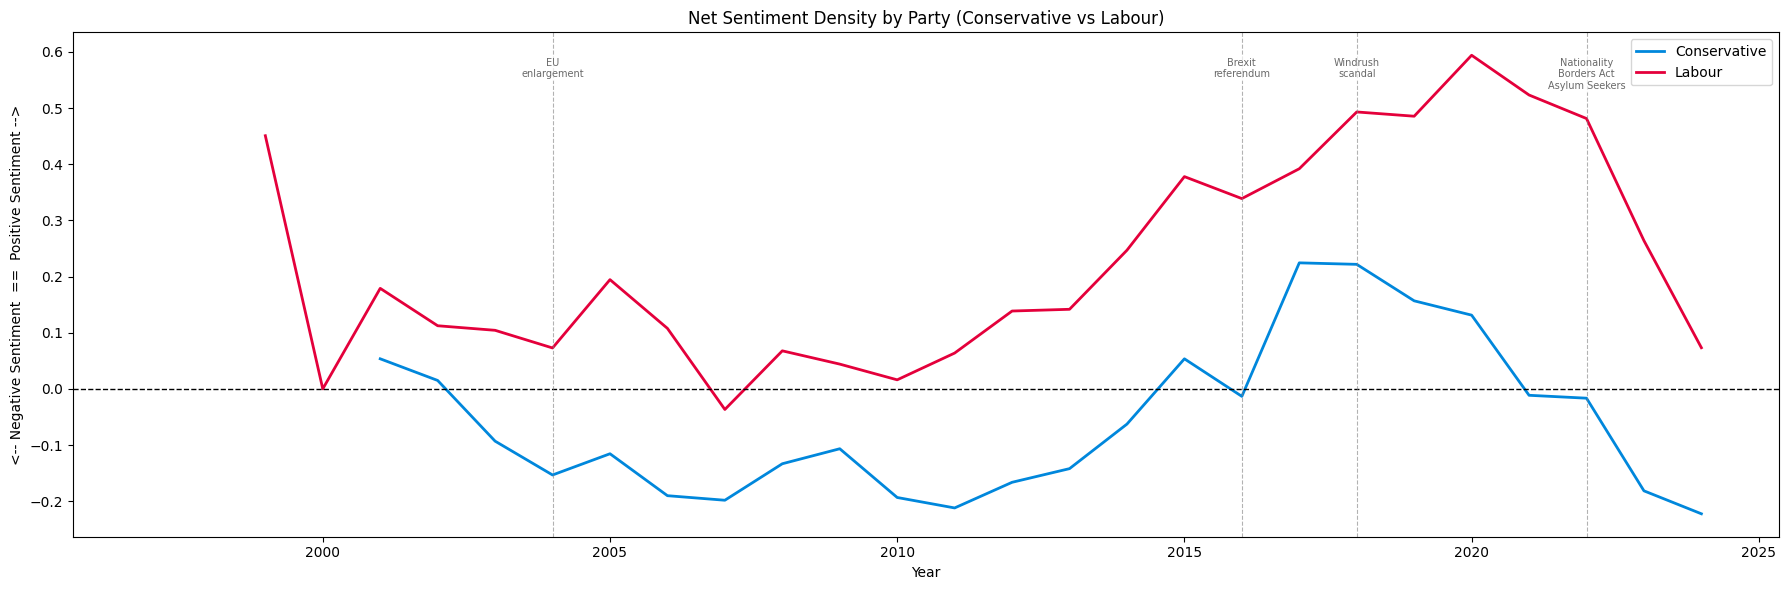

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), sharey=True)

# current HM's Most Loyal Opposition and HM's Government
target_parties = ["Conservative", "Labour"]

for party in target_parties:
    color = party_colors[party]
    party_sent = sent_df[sent_df["current_party"] == party]
    yearly_total_p = party_sent.groupby("year").size()

    # Positive density
    yearly_pos_p = party_sent[party_sent["sentiment_pred"] == "POSITIVE"].groupby("year").size()
    pos_d = (yearly_pos_p / yearly_total_p).dropna()
    pos_s = pos_d.rolling(window=5, center=True, min_periods=2).mean()

    # Negative density
    yearly_neg_p = party_sent[party_sent["sentiment_pred"] == "NEGATIVE"].groupby("year").size()
    neg_d = (yearly_neg_p / yearly_total_p).dropna()
    neg_s = neg_d.rolling(window=5, center=True, min_periods=2).mean()

    # net sentiment = positive - negative
    plotting_d = pos_d.copy() - neg_d.copy()
    axes.plot(plotting_d.index, plotting_d.values, color=color, linewidth=2, label=party)

axes.axhline(0, color='black', linestyle='--', linewidth=1)
axes.set_xlabel("Year")
axes.set_ylabel("<-- Negative Sentiment  ==  Positive Sentiment -->")
axes.set_title("Net Sentiment Density by Party (Conservative vs Labour)")
axes.legend()
annotate_events(axes, events_post20s, y_position="top") # comment this line to remove historical events
plt.tight_layout()
plt.savefig("plot4_party_sentiment_main_parties.png", dpi=150)
plt.show()

### Invite Liberal Democrats and/or SNP to the party?
- pros:
  - Lib Dems are known for pro-immigrant, pro-eu
  - SNP are left-wing nationalist, how a party focusing on independence treats immigrants are interesting
  - UK is not like US that has only two parties
- cons:
  - limiting data for SNP
  - Lab are government and Conv has shadow cabinet, if I include one of the rest opposites why don't I include everything?

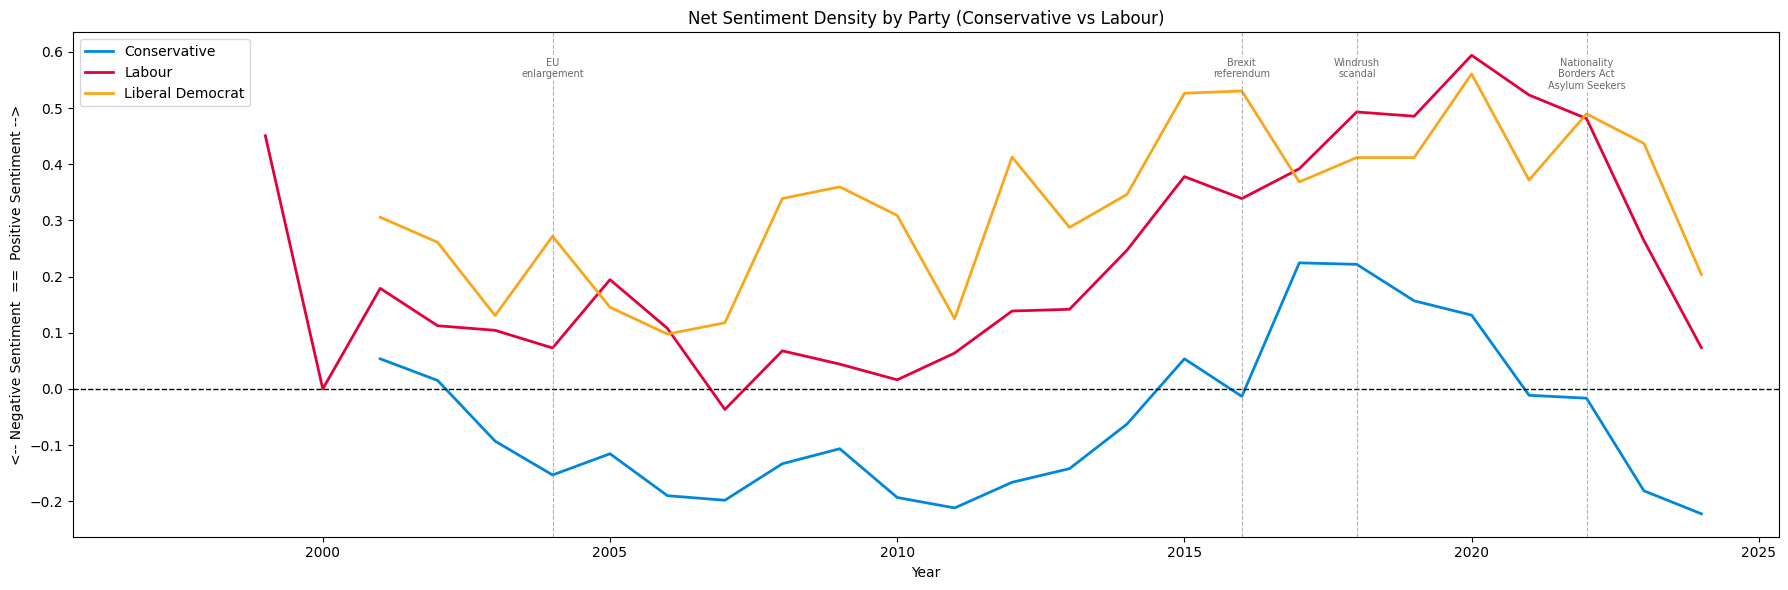

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), sharey=True)

target_parties = ["Conservative", "Labour", "Liberal Democrat"]

for party in target_parties:
    color = party_colors[party]
    party_sent = sent_df[sent_df["current_party"] == party]
    yearly_total_p = party_sent.groupby("year").size()

    # Positive density
    yearly_pos_p = party_sent[party_sent["sentiment_pred"] == "POSITIVE"].groupby("year").size()
    pos_d = (yearly_pos_p / yearly_total_p).dropna()
    pos_s = pos_d.rolling(window=5, center=True, min_periods=2).mean()

    # Negative density
    yearly_neg_p = party_sent[party_sent["sentiment_pred"] == "NEGATIVE"].groupby("year").size()
    neg_d = (yearly_neg_p / yearly_total_p).dropna()
    neg_s = neg_d.rolling(window=5, center=True, min_periods=2).mean()

    # net sentiment = positive - negative
    plotting_d = pos_d.copy() - neg_d.copy()
    axes.plot(plotting_d.index, plotting_d.values, color=color, linewidth=2, label=party)

axes.axhline(0, color='black', linestyle='--', linewidth=1)
axes.set_xlabel("Year")
axes.set_ylabel("<-- Negative Sentiment  ==  Positive Sentiment -->")
axes.set_title("Net Sentiment Density by Party (Conservative vs Labour)")
axes.legend()
annotate_events(axes, events_post20s, y_position="top") # comment this line to remove historical events
plt.tight_layout()
plt.savefig("plot4_party_sentiment_main_parties.png", dpi=150)
plt.show()

Just to my own curiosity, some function helpers that could show the snippets said by a certain person or party. By chaining conditions inside sent_df[...] we could also filter based on sentiments and years

Output cleared, too long

In [ ]:
def show_speaker_snippets(df, speaker_name, n):
    """
    Search for a speaker (case-insensitive partial match) and display their snippets.

    df: dataframe (rel_df or sent_df)
    speaker_name: full or partial name to search for
    n: max number of snippets to show
    """
    mask = df["speakername"].str.contains(speaker_name, case=False, na=False)
    results = df[mask]

    print(f"Found {len(results)} snippets for '{speaker_name}'")
    print(f"Parties: {results['current_party'].unique()}")
    print(f"Year range: {results['year'].min()} - {results['year'].max()}")
    print("=" * 80)

    for i, (_, row) in enumerate(results.head(n).iterrows()):
        print(f"\n--- Snippet {i+1} | {row['year']} | {row['current_party']} ---")
        print(row["snippet"])
        if "relevance_pred" in row:
            print(f"  Relevance: {row['relevance_pred']}")
        if "sentiment_pred" in row:
            print(f"  Sentiment: {row['sentiment_pred']}")
        print()

In [ ]:
def show_party_snippets(df, party_name, n):
    """
    Search for a party (case-insensitive partial match) and display their snippets.

    df: dataframe (rel_df or sent_df)
    party_name: full or partial party name
    n: max number of snippets to show
    """
    mask = df["current_party"].str.contains(party_name, case=False, na=False)
    results = df[mask]

    print(f"Found {len(results)} snippets for '{party_name}'")
    print(f"Speakers: {results['speakername'].nunique()} unique")
    print(f"Year range: {results['year'].min()} - {results['year'].max()}")
    print("=" * 80)

    for i, (_, row) in enumerate(results.head(n).iterrows()):
        print(f"\n--- Snippet {i+1} | {row['speakername']} | {row['year']} ---")
        print(row["snippet"])
        if "relevance_pred" in row:
            print(f"  Relevance: {row['relevance_pred']}")
        if "sentiment_pred" in row:
            print(f"  Sentiment: {row['sentiment_pred']}")
        print()

In [ ]:
show_party_snippets(sent_df[sent_df["sentiment_pred"] == "NEGATIVE"], "Plaid Cymru", n=5)
show_speaker_snippets(sent_df, "Liz Saville-Roberts", n=5)

In [ ]:
show_party_snippets(sent_df, "Scottish National Party", n=5)
show_speaker_snippets(sent_df, "Stephen Flynn", n=5)

In [ ]:
show_speaker_snippets(sent_df[sent_df["sentiment_pred"] == "NEGATIVE"], "Jeremy Corbyn", n=5)
show_speaker_snippets(sent_df[sent_df["sentiment_pred"] == "POSITIVE"], "Jeremy Corbyn", n=5)